# Speech Emotion Recognition using Wav2Vec2
## Fine-tuned on CREMA-D Dataset

**Goal:** Build a model that listens to someone speak and identifies their emotion —
angry, disgust, fear, happy, neutral, or sad.

**How:** We take Facebook's pretrained `wav2vec2-base` model (already trained on 960 hours
of speech) and fine-tune it on the CREMA-D dataset using a technique called
**gradual unfreezing** — we slowly unfreeze more and more layers of the model
across 4 training phases instead of training everything at once.

**Dataset:** CREMA-D — 7,442 `.wav` clips recorded by 91 actors expressing 6 emotions.

---


## Step 1 — Download the Dataset

CREMA-D is available on Kaggle. Each filename encodes the emotion, e.g. `1001_DFA_ANG_XX.wav` — the third part `ANG` tells us the emotion is *angry*.

In [ ]:
# Run this first to get CREMA-D dataset
import kagglehub
ejlok1_cremad_path = kagglehub.dataset_download('ejlok1/cremad')
print('Data source import complete.')


Using Colab cache for faster access to the 'cremad' dataset.
Data source import complete.


## Step 2 — Install Required Libraries

In [ ]:
!pip install transformers datasets torchaudio scikit-learn -q


## Step 3 — Imports and Random Seed

We set `SEED = 42` everywhere so the experiment is fully reproducible —
running this notebook twice gives the exact same train/val/test split
and the same results.

In [ ]:
import os, io, random
import torch
import torchaudio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import Dict, List, Union

from datasets import Dataset, ClassLabel
from transformers import (
    Wav2Vec2Processor,
    Wav2Vec2ForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print("Imports OK | torch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU - enable GPU in Colab!")


Imports OK | torch: 2.10.0+cu128
GPU: Tesla T4


## Step 4 — Audio Constants

Wav2Vec2 was pretrained on audio at **16,000 Hz**, so every clip must be
converted to that sample rate. We also fix every clip to exactly **4 seconds**
(= 64,000 samples) — clips shorter than 4 s are zero-padded at the end,
and clips longer than 4 s are cropped. This gives the model a consistent
input size every single time.


In [ ]:
SAMPLE_RATE  = 16_000
MAX_DURATION = 4
MAX_SAMPLES  = SAMPLE_RATE * MAX_DURATION   # 64000

EMOTION_MAP = {
    "ANG": "angry",
    "DIS": "disgust",
    "FEA": "fear",
    "HAP": "happy",
    "NEU": "neutral",
    "SAD": "sad",
}
print("MAX_SAMPLES:", MAX_SAMPLES)


MAX_SAMPLES: 64000


## Step 5 — Load Dataset Files

We walk through every `.wav` file in the dataset folder, extract the emotion
label from the filename, and build a simple DataFrame with two columns:
`path` (where the file is) and `emotion` (what emotion it is).

In [ ]:
data_path = os.path.join(ejlok1_cremad_path, "AudioWAV")

paths, labels = [], []
for file in sorted(os.listdir(data_path)):
    if file.endswith(".wav"):
        parts = file.split("_")
        if len(parts) >= 3 and parts[2] in EMOTION_MAP:
            paths.append(os.path.join(data_path, file))
            labels.append(EMOTION_MAP[parts[2]])

df = pd.DataFrame({"path": paths, "emotion": labels})
print("Total samples:", len(df))
print(df["emotion"].value_counts())


Total samples: 7442
emotion
angry      1271
disgust    1271
fear       1271
happy      1271
sad        1271
neutral    1087
Name: count, dtype: int64


## Step 6 — Encode Emotion Labels as Numbers

Neural networks work with numbers, not strings.
We create a consistent mapping: `angry=0, disgust=1, fear=2, happy=3, neutral=4, sad=5`.
We also keep the reverse mapping (`id2label`) so we can convert predictions back
to readable emotion names later.

In [ ]:
label_list = sorted(df["emotion"].unique())
label2id   = {label: i for i, label in enumerate(label_list)}
id2label   = {i: label for label, i in label2id.items()}
df["label"] = df["emotion"].map(label2id)
print("label2id:", label2id)


label2id: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5}


## Step 7 — Handle Class Imbalance with Weighted Loss

Looking at the dataset, `neutral` has fewer examples than the other emotions.
If we ignore this, the model will tend to predict majority classes more often
and neglect minority ones.

**Fix:** We use **weighted cross-entropy loss** — emotions with fewer samples
get a higher loss weight so the model is penalised more for getting them wrong.
The formula is: `weight = total / (n_classes × count_per_class)`.


In [ ]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(label_list)),
    y=df["label"].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", {id2label[i]: round(w, 3) for i, w in enumerate(class_weights)})


Class weights: {'angry': np.float64(0.976), 'disgust': np.float64(0.976), 'fear': np.float64(0.976), 'happy': np.float64(0.976), 'neutral': np.float64(1.141), 'sad': np.float64(0.976)}


## Step 8 — Train / Validation / Test Split (80 / 10 / 10)

We split data into **three** separate sets:

| Set | Size | Role |
|---|---|---|
| **Train** | 80% | Model learns from this |
| **Validation** | 10% | Used during training to pick the best checkpoint (early stopping) |
| **Test** | 10% | Completely held out — only used once at the very end |

The test set is **never touched during training**. This gives us an honest,
unbiased estimate of how the model performs on new data it has never seen.

We use **stratified splitting** so each split contains the same proportion
of each emotion as the full dataset.


Train :  5953 samples  (80%)
Val   :   744 samples  (10%)
Test  :   745 samples  (10%)


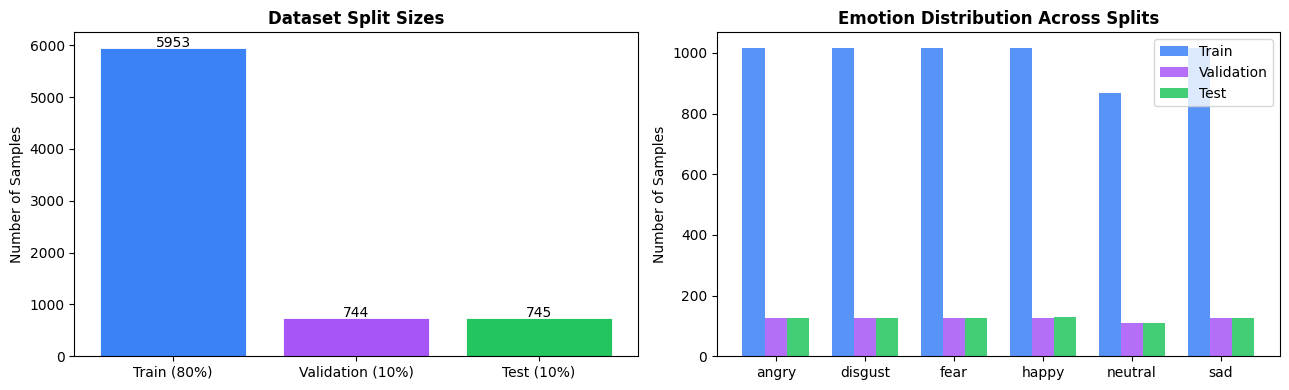

Casting the dataset:   0%|          | 0/5953 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/744 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/745 [00:00<?, ? examples/s]


HuggingFace datasets ready.


In [ ]:
# Step 1: split off 20% as temp holdout (val + test)
train_df, temp_df = train_test_split(
    df, test_size=0.20, random_state=SEED, stratify=df["label"]
)

# Step 2: split temp 50/50 → val (10%) and test (10%)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train : {len(train_df):5d} samples  (80%)")
print(f"Val   : {len(val_df):5d} samples  (10%)")
print(f"Test  : {len(test_df):5d} samples  (10%)")

# ── Plot 1: overall split sizes ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

split_names  = ["Train (80%)", "Validation (10%)", "Test (10%)"]
split_counts = [len(train_df), len(val_df), len(test_df)]
split_colors = ["#3b82f6", "#a855f7", "#22c55e"]

axes[0].bar(split_names, split_counts, color=split_colors, edgecolor="white", linewidth=0.6)
axes[0].set_title("Dataset Split Sizes", fontweight="bold")
axes[0].set_ylabel("Number of Samples")
for i, v in enumerate(split_counts):
    axes[0].text(i, v + 20, str(v), ha="center", fontsize=10)

# ── Plot 2: per-emotion count in each split (grouped bar) ─────────────────
x       = range(len(label_list))
width   = 0.25
tr_cnts = [len(train_df[train_df["emotion"] == e]) for e in label_list]
va_cnts = [len(val_df  [val_df["emotion"]   == e]) for e in label_list]
te_cnts = [len(test_df [test_df["emotion"]  == e]) for e in label_list]

axes[1].bar([i - width for i in x], tr_cnts, width, label="Train",      color="#3b82f6", alpha=0.85)
axes[1].bar([i         for i in x], va_cnts, width, label="Validation", color="#a855f7", alpha=0.85)
axes[1].bar([i + width for i in x], te_cnts, width, label="Test",       color="#22c55e", alpha=0.85)
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(label_list)
axes[1].set_title("Emotion Distribution Across Splits", fontweight="bold")
axes[1].set_ylabel("Number of Samples")
axes[1].legend()

plt.tight_layout()
plt.savefig("split_distribution.png", dpi=150)
plt.show()

# ── Convert to HuggingFace datasets ──────────────────────────────────────
train_dataset = Dataset.from_pandas(train_df[["path", "emotion", "label"]])
val_dataset   = Dataset.from_pandas(val_df[["path",   "emotion", "label"]])
test_dataset  = Dataset.from_pandas(test_df[["path",  "emotion", "label"]])

train_dataset = train_dataset.cast_column("label", ClassLabel(names=label_list))
val_dataset   = val_dataset.cast_column("label",   ClassLabel(names=label_list))
test_dataset  = test_dataset.cast_column("label",  ClassLabel(names=label_list))

print("\nHuggingFace datasets ready.")


## Step 9 — Load the Wav2Vec2 Processor

The processor is the audio equivalent of a text tokenizer.
It takes a raw numpy array of audio samples and converts it into
`input_values` — the numerical format the model expects.

We load it from the same pretrained checkpoint we'll use for the model.


In [ ]:
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
print("Processor loaded")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

Processor loaded


## Step 10 — Audio Preprocessing Function

Every audio clip goes through this pipeline before being fed to the model:

```
Load WAV  →  Resample to 16 kHz  →  Stereo to Mono
  →  Crop / Pad to exactly 4 s  →  Normalize to [-1, 1]
  →  [Training only] Add noise / scale volume  →  Wav2Vec2Processor
```

**Why augmentation during training?**
The model trains on clean studio recordings but will run on noisy microphone
input. Adding small amounts of random noise during training makes the model
more robust to real-world conditions.


In [ ]:
def load_and_preprocess(example, augment=False):
    speech, sr = torchaudio.load(example["path"])

    if sr != SAMPLE_RATE:
        speech = torchaudio.functional.resample(speech, sr, SAMPLE_RATE)

    if speech.shape[0] > 1:
        speech = speech.mean(dim=0, keepdim=True)

    speech = speech.squeeze().numpy()

    # Crop or zero-pad to exactly MAX_SAMPLES
    if len(speech) > MAX_SAMPLES:
        speech = speech[:MAX_SAMPLES]
    else:
        speech = np.pad(speech, (0, MAX_SAMPLES - len(speech)))

    # Normalize BEFORE processor
    max_val = np.max(np.abs(speech))
    if max_val > 1e-8:
        speech = speech / max_val

    # Verify normalization
    assert np.max(np.abs(speech)) <= 1.0 + 1e-6, f"Normalization failed: {np.max(np.abs(speech))}"

    if augment:
        if random.random() < 0.5:
            noise_amp = random.uniform(0.001, 0.015)
            speech = speech + noise_amp * np.random.randn(len(speech))
            speech = np.clip(speech, -1.0, 1.0)
        if random.random() < 0.3:
            speech = speech * random.uniform(0.7, 1.0)

    # Pass raw normalized numpy array directly
    inputs = processor(
        speech,
        sampling_rate=SAMPLE_RATE,
        return_tensors="np",
        padding=False,
    )
    example["input_values"] = inputs["input_values"][0]
    return example

def preprocess_train(ex): return load_and_preprocess(ex, augment=True)
def preprocess_eval(ex):  return load_and_preprocess(ex, augment=False)


## Step 11 — Sanity Check

Before preprocessing 7,000+ files, we test the pipeline on a single sample.
If something is broken (wrong shape, NaN values, etc.) this catches it
immediately rather than wasting GPU time.

In [ ]:
# Sanity check on ONE sample before mapping the whole dataset
sample = dict(train_dataset[0])
sample = load_and_preprocess(sample, augment=False)
vals = np.array(sample["input_values"])
print(f"Shape : {vals.shape}")
print(f"Min   : {vals.min():.4f}")
print(f"Max   : {vals.max():.4f}")
print(f"NaN   : {np.isnan(vals).any()}")
print(f"Inf   : {np.isinf(vals).any()}")

# NOTE: After Wav2Vec2Processor, values are NOT limited to [-1,1]
# The processor applies its own feature normalization — large values are normal.
# We only check shape and that there are no NaN/Inf values.
assert vals.shape[0] == MAX_SAMPLES, f"Wrong length: {vals.shape[0]} (expected {MAX_SAMPLES})"
assert not np.isnan(vals).any(), "NaN values found!"
assert not np.isinf(vals).any(), "Inf values found!"
print("Sanity check PASSED - shape and NaN/Inf checks OK")
print("(Large min/max values after processor are normal and expected)")


Shape : (64000,)
Min   : -8.0902
Max   : 8.2974
NaN   : False
Inf   : False
Sanity check PASSED - shape and NaN/Inf checks OK
(Large min/max values after processor are normal and expected)


## Step 12 — Preprocess All Three Splits

We run the preprocessing function across every sample using `.map()`.
`num_proc=2` runs two CPU workers in parallel to speed this up.

Augmentation is **only** applied to training data — validation and test
use the clean version so our metrics reflect real-world conditions.


In [ ]:
print("Mapping train dataset...")
train_dataset = train_dataset.map(preprocess_train, remove_columns=["path", "emotion"], num_proc=2)
print("Mapping val dataset...")
val_dataset   = val_dataset.map(preprocess_eval,   remove_columns=["path", "emotion"], num_proc=2)
print("Mapping test dataset...")
test_dataset  = test_dataset.map(preprocess_eval,  remove_columns=["path", "emotion"], num_proc=2)
print("Done")


Mapping train dataset...


Map (num_proc=2):   0%|          | 0/5953 [00:00<?, ? examples/s]

Mapping val dataset...


Map (num_proc=2):   0%|          | 0/744 [00:00<?, ? examples/s]

Mapping test dataset...


Map (num_proc=2):   0%|          | 0/745 [00:00<?, ? examples/s]

Done


## Step 13 — Convert to PyTorch Tensors

This tells HuggingFace to return PyTorch tensors when samples are accessed, which is what the training loop expects.

In [ ]:
train_dataset.set_format(type="torch", columns=["input_values", "label"])
val_dataset.set_format(  type="torch", columns=["input_values", "label"])
test_dataset.set_format( type="torch", columns=["input_values", "label"])
print("Formats set")


Formats set


## Step 14 — Load Pretrained Wav2Vec2 Model

We load `facebook/wav2vec2-base` — pretrained by Facebook AI on 960 hours
of unlabelled English speech using self-supervised learning. It already has
a very strong understanding of speech sounds.

On top of it we attach a fresh classification head for our 6 emotions.

**Phase 1 strategy:** We freeze everything (the CNN feature extractor
and all 12 transformer layers) so only the brand-new classifier head trains.
This is important — if we immediately train all 90M parameters on a small
dataset, we risk destroying the pretrained knowledge.


In [ ]:
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-base",
    num_labels=len(label_list),
    label2id=label2id,
    id2label=id2label,
)

# Freeze EVERYTHING except the classifier head
model.freeze_feature_encoder()
for param in model.wav2vec2.parameters():
    param.requires_grad = False  # freeze all transformer layers too

# Verify
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total: {total:,} | Trainable: {trainable:,}")
# Should show only ~5K-20K trainable (just the classifier head)


pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_hid.bias             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
classifier.weight            | MISSING    | 
projector.bias               | MISSING    | 
classifier.bias              | MISSING    | 
projector.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total: 94,570,118 | Trainable: 198,406


## Step 15 — Data Collator and Metrics

**Data Collator:** Groups individual samples into batches. It pads clips to
the same length within each batch and stacks the labels into a tensor.

**Metrics:** We report accuracy and weighted F1 after each epoch.
Weighted F1 is more informative than accuracy when classes are imbalanced —
it accounts for how many samples each class has.

In [ ]:
@dataclass
class AudioDataCollator:
    processor: Wav2Vec2Processor
    padding: bool = True

    def __call__(self, features):
        input_values = [{"input_values": f["input_values"]} for f in features]
        labels = torch.tensor([f["label"] for f in features], dtype=torch.long)
        batch = self.processor.pad(input_values, padding=self.padding, return_tensors="pt")
        batch["labels"] = labels
        return batch

data_collator = AudioDataCollator(processor=processor)

def compute_metrics(pred):
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        pred.label_ids, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(pred.label_ids, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}


## Step 16 — Custom Trainer with Weighted Loss

The standard HuggingFace `Trainer` uses plain cross-entropy which treats
all classes equally. We subclass it and override `compute_loss` to inject
our class weights — so underrepresented emotions like `neutral` contribute
more to the loss and the model can't just ignore them.


In [ ]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        device = "cuda" if torch.cuda.is_available() else "cpu"
        self.class_weights = class_weights.to(device)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = torch.nn.CrossEntropyLoss(weight=self.class_weights)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


## Step 17 — Phase 1: Train the Classifier Head Only

We train just the newly added classifier head for 3 epochs.
Everything else (the 12 transformer layers + CNN) stays frozen.

Using a relatively high learning rate (`1e-3`) is fine here because
there are very few trainable parameters. Early stopping kicks in after
2 epochs with no improvement in F1 on the **validation set**.


In [ ]:
# PHASE 1: Train classifier head only — 3 epochs
args_p1 = TrainingArguments(
    output_dir="./results_phase1",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=1e-3,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    warmup_steps=100,
    weight_decay=0.01,
    fp16=True,
    max_grad_norm=1.0,
    save_total_limit=1,
    report_to="none",
    seed=SEED,
)

trainer_p1 = WeightedTrainer(
    class_weights=class_weights_tensor,
    model=model,
    args=args_p1,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,     # val set used for early stopping — test kept untouched
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Phase 1 starting — should see accuracy rise above 17% quickly")
trainer_p1.train()
print("Phase 1 complete")


Phase 1 starting — should see accuracy rise above 17% quickly


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.394485,1.622529,0.364247,0.322657,0.427987,0.364247
2,1.276003,1.547102,0.424731,0.402380,0.541972,0.424731
3,1.237511,1.453235,0.430108,0.386995,0.493627,0.430108


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Phase 1 complete


## Step 18 — Phase 2: Gradual Unfreezing (2a → 2b → 2c)

Now we progressively unfreeze more transformer layers, working from the
**top of the model downward**. Top layers are the most task-specific
(closest to the output) so they benefit most from fine-tuning.
Bottom layers hold general speech knowledge we want to preserve.

| Sub-phase | Layers unfrozen | Learning rate | Reason |
|---|---|---|---|
| **2a** | Top 4 layers (8–11) + head | 1e-4 | Start adapting task-specific layers |
| **2b** | Middle 4 layers (4–7) added | 5e-6 | Deeper layers need smaller LR |
| **2c** | Full model (all layers) | 1e-5 | Final end-to-end polish |

The validation set drives early stopping throughout.
The test set is still completely untouched.


In [ ]:
import numpy as np

# ── helper ──────────────────────────────────────────────────────────────────
def set_trainable(named_params, requires_grad):
    for _, p in named_params:
        p.requires_grad = requires_grad

def print_trainable(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total: {total:,} | Trainable: {trainable:,} ({100*trainable/total:.1f}%)")

# ── make sure everything is frozen coming out of Phase 1 ────────────────────
for param in model.parameters():
    param.requires_grad = False
# keep classifier head trainable
for param in model.projector.parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True


# ════════════════════════════════════════════════════════════════════════════
# SUB-PHASE 2a — last 4 transformer layers  (epochs 1-4)
# ════════════════════════════════════════════════════════════════════════════
for i in range(8, 12):          # layers 8-11
    for p in model.wav2vec2.encoder.layers[i].parameters():
        p.requires_grad = True

print("Sub-phase 2a: last 4 transformer layers + head")
print_trainable(model)

args_2a = TrainingArguments(
    output_dir       = "./results_phase2a",
    num_train_epochs = 4,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 8,
    learning_rate    = 1e-4,       # higher — only shallow layers unfrozen
    eval_strategy    = "epoch",
    save_strategy    = "epoch",
    logging_steps    = 50,
    load_best_model_at_end  = True,
    metric_for_best_model   = "f1",
    greater_is_better       = True,
    warmup_steps     = 100,
    weight_decay     = 0.01,
    fp16             = True,
    max_grad_norm    = 1.0,
    save_total_limit = 1,
    report_to        = "none",
    seed             = SEED,
)

trainer_2a = WeightedTrainer(
    class_weights  = class_weights_tensor,
    model          = model,
    args           = args_2a,
    train_dataset  = train_dataset,
    eval_dataset   = val_dataset,
    data_collator  = data_collator,
    compute_metrics= compute_metrics,
    callbacks      = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Sub-phase 2a starting...")
trainer_2a.train()
res = trainer_2a.evaluate()
print(f"  2a → F1={res['eval_f1']:.4f}  Acc={res['eval_accuracy']:.4f}")


# ════════════════════════════════════════════════════════════════════════════
# SUB-PHASE 2b — middle 4 layers added  (epochs 1-4)
# ════════════════════════════════════════════════════════════════════════════
for i in range(4, 8):           # layers 4-7
    for p in model.wav2vec2.encoder.layers[i].parameters():
        p.requires_grad = True

# also unfreeze positional conv
for p in model.wav2vec2.encoder.pos_conv_embed.parameters():
    p.requires_grad = True

print("\nSub-phase 2b: middle layers added")
print_trainable(model)

args_2b = TrainingArguments(
    output_dir       = "./results_phase2b",
    num_train_epochs = 6,
    per_device_train_batch_size = 16,        # was 8
    per_device_eval_batch_size  = 16,        # was 8
    learning_rate    = 5e-6,                 # was 3e-5 (too high)
    lr_scheduler_type = "cosine",            # added
    eval_strategy    = "epoch",
    save_strategy    = "epoch",
    logging_steps    = 50,
    load_best_model_at_end  = True,
    metric_for_best_model   = "f1",
    greater_is_better       = True,
    warmup_steps     = 200,                  # was 150
    weight_decay     = 0.08,                 # was 0.01
    fp16             = True,
    max_grad_norm    = 0.3,                  # was 1.0
    save_total_limit = 1,
    report_to        = "none",
    seed             = SEED,
)

trainer_2b = WeightedTrainer(
    class_weights  = class_weights_tensor,
    model          = model,
    args           = args_2b,
    train_dataset  = train_dataset,
    eval_dataset   = val_dataset,
    data_collator  = data_collator,
    compute_metrics= compute_metrics,
    callbacks      = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Sub-phase 2b starting...")
trainer_2b.train()
res = trainer_2b.evaluate()
print(f"  2b → F1={res['eval_f1']:.4f}  Acc={res['eval_accuracy']:.4f}")


# ════════════════════════════════════════════════════════════════════════════
# SUB-PHASE 2c — full model end-to-end  (epochs 1-4)
# ════════════════════════════════════════════════════════════════════════════
for param in model.parameters():
    param.requires_grad = True

print("\nSub-phase 2c: full model")
print_trainable(model)

args_2c = TrainingArguments(
    output_dir       = "./results_phase2c",
    num_train_epochs = 4,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 8,
    learning_rate    = 1e-5,       # lowest — full model unfrozen
    eval_strategy    = "epoch",
    save_strategy    = "epoch",
    logging_steps    = 50,
    load_best_model_at_end  = True,
    metric_for_best_model   = "f1",
    greater_is_better       = True,
    warmup_steps     = 200,
    weight_decay     = 0.01,
    fp16             = True,
    max_grad_norm    = 1.0,
    save_total_limit = 2,
    report_to        = "none",
    seed             = SEED,
)

trainer_2c = WeightedTrainer(
    class_weights  = class_weights_tensor,
    model          = model,
    args           = args_2c,
    train_dataset  = train_dataset,
    eval_dataset   = val_dataset,
    data_collator  = data_collator,
    compute_metrics= compute_metrics,
    callbacks      = [EarlyStoppingCallback(early_stopping_patience=3)],
)

print("Sub-phase 2c starting...")
trainer_2c.train()

# ── Final evaluation ─────────────────────────────────────────────────────────
print("\nFinal Results:")
results = trainer_2c.evaluate()
for k, v in results.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Sub-phase 2a: last 4 transformer layers + head
  Total: 94,570,118 | Trainable: 28,549,894 (30.2%)
Sub-phase 2a starting...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.011022,1.176337,0.549731,0.504563,0.609095,0.549731
2,0.894666,1.147541,0.594086,0.590523,0.670956,0.594086
3,0.700382,0.863020,0.692204,0.688952,0.709201,0.692204
4,0.540354,0.795138,0.737903,0.734635,0.744259,0.737903


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Final Results:


  eval_loss: 0.9794
  eval_accuracy: 0.7661
  eval_f1: 0.7640
  eval_precision: 0.7644
  eval_recall: 0.7661
  eval_runtime: 5.6048
  eval_samples_per_second: 132.7430
  eval_steps_per_second: 16.5930
  epoch: 4.0000


## Step 19 — Final Evaluation on the Held-Out Test Set

This is the only time we run on the test set. It was never used during
training or for any decisions (which checkpoint to save, when to stop).
So these numbers are a true, unbiased measure of real-world performance.


In [ ]:
# Final evaluation on the HELD-OUT test set
# This is the only time we touch test_dataset — gives an honest accuracy number
results = trainer_2c.evaluate(eval_dataset=test_dataset)

print("Final Results on Test Set:")
for k, v in results.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")


Final Results on Test Set:
eval_loss: 1.0680
eval_accuracy: 0.7678
eval_f1: 0.7654
eval_precision: 0.7717
eval_recall: 0.7678
eval_runtime: 5.7038
eval_samples_per_second: 130.6150
eval_steps_per_second: 16.4800
epoch: 4.0000


## Step 20 — Confusion Matrix

Shows which emotions the model gets right and which it confuses.
The diagonal (top-left to bottom-right) = correct predictions.
Off-diagonal = errors. For example, if fear is often predicted as sad,
that cell will be a darker blue.


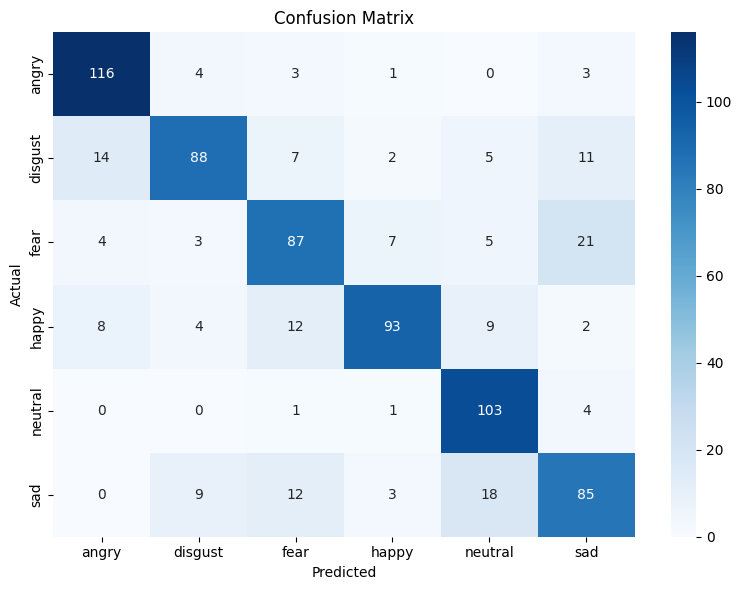

              precision    recall  f1-score   support

       angry       0.82      0.91      0.86       127
     disgust       0.81      0.69      0.75       127
        fear       0.71      0.69      0.70       127
       happy       0.87      0.73      0.79       128
     neutral       0.74      0.94      0.83       109
         sad       0.67      0.67      0.67       127

    accuracy                           0.77       745
   macro avg       0.77      0.77      0.77       745
weighted avg       0.77      0.77      0.77       745



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

predictions = trainer_2c.predict(test_dataset)
preds       = predictions.predictions.argmax(-1)
true_labels = predictions.label_ids

cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_list, yticklabels=label_list)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print(classification_report(true_labels, preds, target_names=label_list))


## Step 21 — Save the Model

We save the trained model weights and processor config so we can
load and use the model later without retraining.

Download the `ser_wav2vec2_best/` folder from the **Kaggle Output tab**
and place it in your project folder to use with the Flask app.

In [ ]:
model.save_pretrained("./ser_wav2vec2_best")
processor.save_pretrained("./ser_wav2vec2_best")
print("Model saved!")
print("Files:", os.listdir("./ser_wav2vec2_best"))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved!
Files: ['model.safetensors', 'processor_config.json', 'config.json', 'vocab.json', 'tokenizer_config.json']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model.save_pretrained("/content/drive/MyDrive/ser_wav2vec2_best")
processor.save_pretrained("/content/drive/MyDrive/ser_wav2vec2_best")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['/content/drive/MyDrive/ser_wav2vec2_best/processor_config.json']

## Step 22 — Additional Evaluation Plots

Four extra plots to better understand model performance:

1. **Per-class Precision, Recall & F1** — breaks down performance per emotion
2. **Training loss curve** — shows how loss dropped across all 4 phases
3. **Per-class accuracy** — which emotions are easiest / hardest
4. **Confidence distribution** — is the model uncertain when it's wrong?



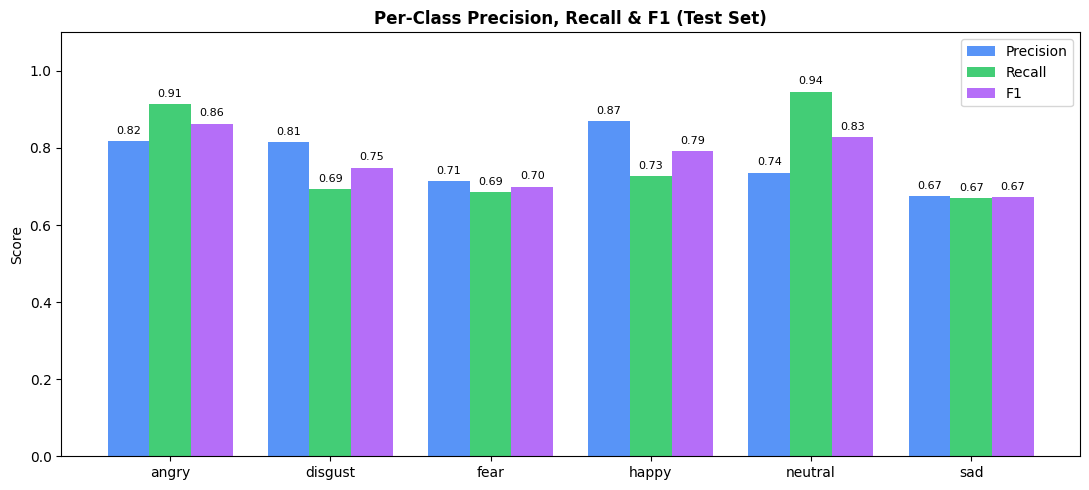

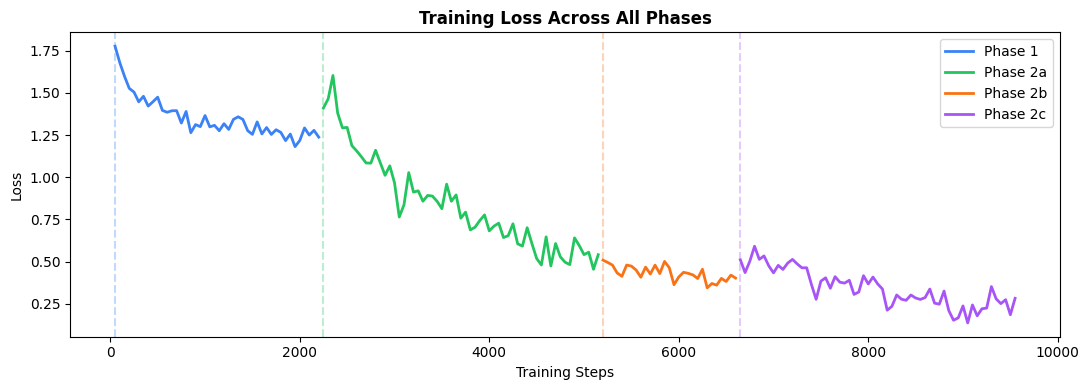

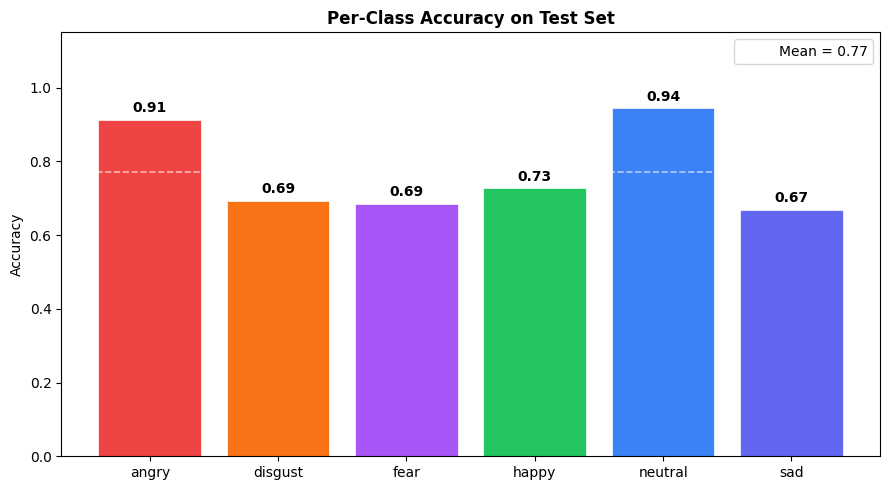

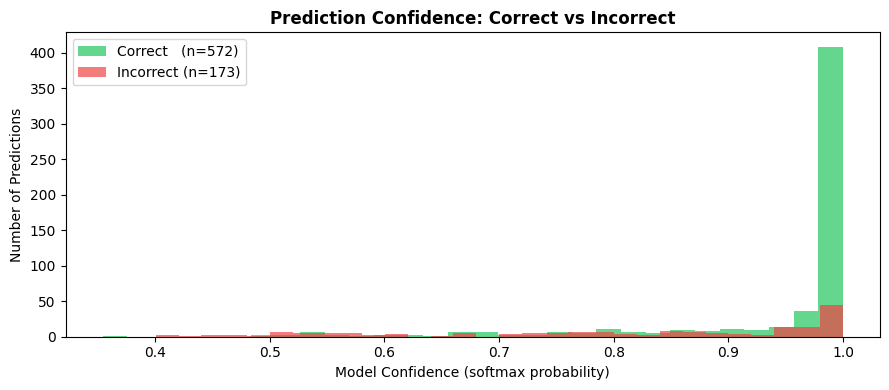

Avg confidence when CORRECT  : 0.948
Avg confidence when INCORRECT: 0.818


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

# ── Run predictions on test set (reuse if already done above) ─────────────
predictions = trainer_2c.predict(test_dataset)
preds       = predictions.predictions.argmax(-1)
probs       = torch.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()
true_labels = predictions.label_ids
confidences = probs.max(axis=-1)

COLORS = ["#ef4444","#f97316","#a855f7","#22c55e","#3b82f6","#6366f1"]

# ═══════════════════════════════════════════════════════════════════
# PLOT 1 — Per-class Precision, Recall, F1
# ═══════════════════════════════════════════════════════════════════
precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels, preds, labels=list(range(len(label_list))), zero_division=0
)

x     = np.arange(len(label_list))
width = 0.26

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, precision, width, label="Precision", color="#3b82f6", alpha=0.85)
ax.bar(x,         recall,    width, label="Recall",    color="#22c55e", alpha=0.85)
ax.bar(x + width, f1,        width, label="F1",        color="#a855f7", alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(label_list)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score"); ax.set_title("Per-Class Precision, Recall & F1 (Test Set)", fontweight="bold")
ax.legend()
for i in range(len(label_list)):
    ax.text(i - width, precision[i] + 0.02, f"{precision[i]:.2f}", ha="center", fontsize=8)
    ax.text(i,         recall[i]    + 0.02, f"{recall[i]:.2f}",    ha="center", fontsize=8)
    ax.text(i + width, f1[i]        + 0.02, f"{f1[i]:.2f}",        ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("per_class_metrics.png", dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════════════
# PLOT 2 — Training Loss Curve Across All Phases
# ═══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 4))

phase_colors = {"Phase 1": "#3b82f6", "Phase 2a": "#22c55e",
                "Phase 2b": "#f97316", "Phase 2c": "#a855f7"}

offset = 0
for trainer_obj, label in [
    (trainer_p1,  "Phase 1"),
    (trainer_2a,  "Phase 2a"),
    (trainer_2b,  "Phase 2b"),
    (trainer_2c,  "Phase 2c"),
]:
    log   = trainer_obj.state.log_history
    steps = [offset + e["step"] for e in log if "loss" in e]
    loss  = [e["loss"]          for e in log if "loss" in e]
    if steps:
        ax.plot(steps, loss, label=label, color=phase_colors[label], linewidth=2)
        ax.axvline(x=steps[0], color=phase_colors[label], linestyle="--", alpha=0.3)
        offset = steps[-1]

ax.set_xlabel("Training Steps")
ax.set_ylabel("Loss")
ax.set_title("Training Loss Across All Phases", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("training_loss_curve.png", dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════════════
# PLOT 3 — Per-class Accuracy Bar Chart
# ═══════════════════════════════════════════════════════════════════
per_class_acc = []
for i in range(len(label_list)):
    mask = true_labels == i
    if mask.sum() > 0:
        per_class_acc.append((preds[mask] == true_labels[mask]).mean())
    else:
        per_class_acc.append(0.0)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(label_list, per_class_acc, color=COLORS, edgecolor="white", linewidth=0.5)
ax.set_ylim(0, 1.15)
ax.axhline(y=np.mean(per_class_acc), color="white", linestyle="--",
           linewidth=1.2, alpha=0.6, label=f"Mean = {np.mean(per_class_acc):.2f}")
ax.set_ylabel("Accuracy")
ax.set_title("Per-Class Accuracy on Test Set", fontweight="bold")
ax.legend()
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f"{val:.2f}", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("per_class_accuracy.png", dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════════════
# PLOT 4 — Confidence Distribution: Correct vs Incorrect Predictions
# ═══════════════════════════════════════════════════════════════════
correct   = confidences[preds == true_labels]
incorrect = confidences[preds != true_labels]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(correct,   bins=30, alpha=0.7, color="#22c55e", label=f"Correct   (n={len(correct)})")
ax.hist(incorrect, bins=30, alpha=0.7, color="#ef4444", label=f"Incorrect (n={len(incorrect)})")
ax.set_xlabel("Model Confidence (softmax probability)")
ax.set_ylabel("Number of Predictions")
ax.set_title("Prediction Confidence: Correct vs Incorrect", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("confidence_distribution.png", dpi=150)
plt.show()

print(f"Avg confidence when CORRECT  : {correct.mean():.3f}")
print(f"Avg confidence when INCORRECT: {incorrect.mean():.3f}")